In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "mobeenfatimah/student-career-success-prediction-dataset",'student_career_success_dataset.csv'
)
# carregando dataset do kaggle em formato dataframe

/tmp/ipykernel_307521/3040017050.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "mobeenfatimah/student-career-success-prediction-dataset",'student_career_success_dataset.csv'


In [2]:
import shap
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.preprocessing import OneHotEncoder


In [3]:
df.head()
# primeiras linhas

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256


In [4]:
df.isnull().sum()
# nenhuma coluna com dados nulos

Student_ID               0
Age                      0
Gender                   0
University_Year          0
Major                    0
Attendance_Percentage    0
Study_Hours_Per_Week     0
CGPA                     0
Academic_Performance     0
Programming_Skill        0
Projects_Completed       0
Certifications           0
Hackathons               0
GitHub_Profile           0
Internships              0
Leadership_Experience    0
LinkedIn_Profile         0
Resume_Score             0
Communication_Skills     0
Teamwork                 0
Problem_Solving          0
English_Proficiency      0
Interview_Score          0
Employability_Score      0
Placement_Status         0
Company_Tier             0
Career_Field             0
Placement_Mode           0
Starting_Salary_USD      0
dtype: int64

In [5]:
cols_cat = df.select_dtypes(include="object").columns.tolist()
# separo as colunas categgoricas
cols_cat.remove('Placement_Status')
# tiro o target e o ID
cols_cat.remove('Student_ID')

In [6]:
cols_num = df.select_dtypes(include=["int64","float64"]).columns.tolist()
# colunas numericas

In [7]:
leakage_cols = ['Starting_Salary_USD', 'Company_Tier', 'Career_Field', 'Placement_Mode']
# ao relaizar alguns testes percebi que o modelo estava com a influencia de somente uma categoria, o salario, investigando o dataset, da para perceeber que quando o salario é 0 o Placement_Status é 0
# o modelo aprendeu a roubar ou melhor dizendo houve um vazamento de dados, pois o modelo pela feature saberia sempre que o target era 0 por conta do salario
# isso acoontece para as colunas acima
# enatao a solução é tirar as colunnas da base de treino
cols_cat = [c for c in cols_cat if c not in leakage_cols]
# para cada coluna em colunas categoricas se ela nao estiver na lista de vazamento entao adiciona a variavel cols_cat
cols_num = [c for c in cols_num if c not in leakage_cols]
# mesma coisa é atibuida a colunas numericas

In [8]:
x = df[cols_cat+cols_num]
# concateno as colunas numericas e as categoricas 
y = df['Placement_Status'].map({'Not Placed':0, 'Placed':1})
# fezendo o encoding manual no target
# para cada registro verifica qual das duas opcoes é e troca pelo valor correspondente

In [9]:
y

0        1
1        0
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    1
49998    1
49999    1
Name: Placement_Status, Length: 50000, dtype: int64

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3)
# sepearando os dados de treino e teste

In [11]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cols_cat),
        ('num', 'passthrough', cols_num) 
    ]
    # diz para aplicar o OneHotEncoder apenas para as colunas categoricas, e as numericas deixar como esta
)

x_train_encoded = preprocessor.fit_transform(x_train)
# treino com o encoding aplicado
x_test_encoded = preprocessor.transform(x_test)
# dados de teste

In [12]:
model = LinearSVC()
# instanciando o modelo

In [13]:
model.fit(x_train_encoded,y_train)
# treino do modelo

LinearSVC()

In [14]:
y_test

33632    1
21743    1
9736     1
16732    1
27407    0
        ..
8246     1
45244    1
21477    0
12174    1
16365    1
Name: Placement_Status, Length: 15000, dtype: int64

In [15]:
model.score(x_test_encoded,y_test)
# avaliação do modelo com dados que ainda nao viu

0.8184

In [16]:
feature_names = preprocessor.get_feature_names_out()

  0%|          | 0/15000 [00:00<?, ?it/s]

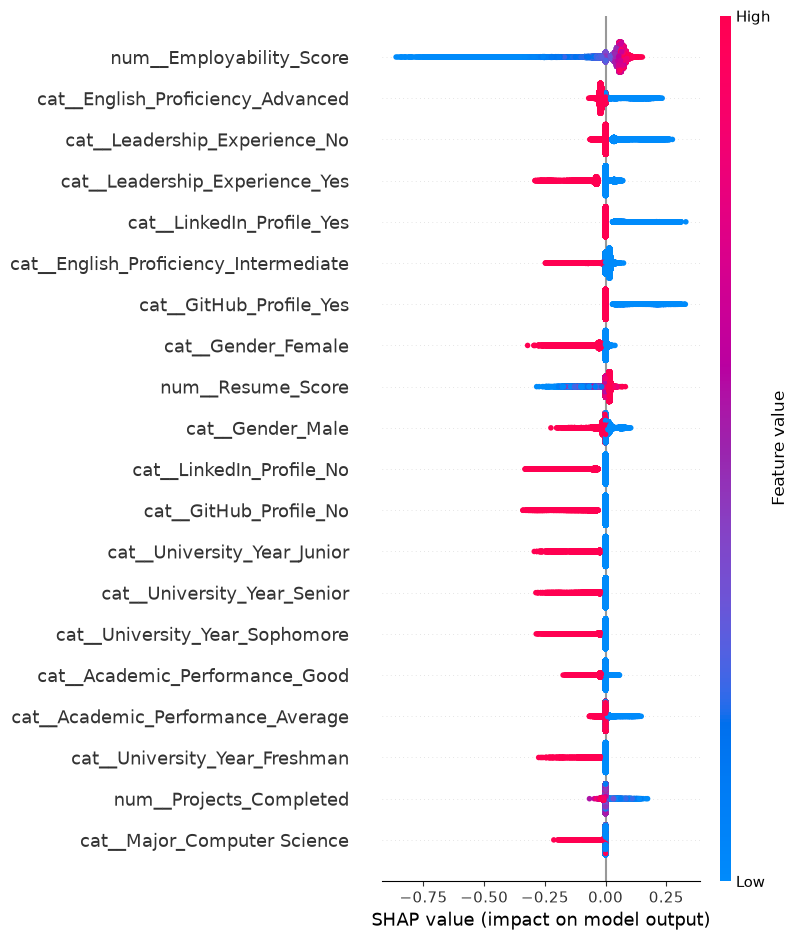

In [17]:
explainer = shap.KernelExplainer(model.predict,shap.kmeans(x_train_encoded,10))
# pega a previsao do modelo com kmeans em 25 pontos medios

shap_values = explainer.shap_values(x_test_encoded)
# calculando o shap para os dados de teste
shap.summary_plot(shap_values,x_test_encoded,feature_names=feature_names)
# plota um grafico para a observação de qual feature influenciou mais a deciisão do modelo

In [18]:
# calculando o valor absoluto de influencia das features para a predição do modelo
mean_abs_shap_values = np.abs(shap_values).mean(axis=0)

import_feature = zip(feature_names,mean_abs_shap_values)

features_importances=sorted(import_feature,key=lambda x: x[1], reverse=True)

for feature,importance in features_importances:
    print(feature, ": ",importance)

num__Employability_Score :  0.08961146774716389
cat__English_Proficiency_Advanced :  0.03476436302688482
cat__Leadership_Experience_No :  0.03294802258426361
cat__Leadership_Experience_Yes :  0.03147768495306738
cat__LinkedIn_Profile_Yes :  0.03027929297203819
cat__English_Proficiency_Intermediate :  0.027716688468503052
cat__GitHub_Profile_Yes :  0.02707467822967391
cat__Gender_Female :  0.026749318049016823
num__Resume_Score :  0.023843208676734826
cat__Gender_Male :  0.023653506608715163
cat__LinkedIn_Profile_No :  0.023417862355390687
cat__GitHub_Profile_No :  0.02108177476883562
cat__University_Year_Junior :  0.015043386977688328
cat__University_Year_Senior :  0.012218509837199819
cat__University_Year_Sophomore :  0.011990444425191595
cat__Academic_Performance_Good :  0.010601161343635082
cat__Academic_Performance_Average :  0.008306234437870945
cat__University_Year_Freshman :  0.008242555625679937
num__Projects_Completed :  0.004906489429716876
cat__Major_Computer Science :  0.00